In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [10]:
# Replace 'filename.csv' with the exact name of the file you downloaded
df = pd.read_csv('Qualtrics.csv')

# Display the first 5 rows of the survey data to verify it loaded correctly
df = df.drop(columns=['StartDate', 'EndDate', 'Progress', 'Duration (in seconds)', 'Finished',
       'RecordedDate', 'ResponseId', 'RecipientLastName', 'RecipientFirstName',
       'RecipientEmail', 'ExternalReference', 'LocationLatitude',
       'LocationLongitude', 'DistributionChannel', 'UserLanguage',
       'Q_BallotBoxStuffing'])
df.head()

,Q1,Q2,Q3,Q4,Q5,Q6,Q12,Q13,Q14,Q14_22_TEXT,...,Q53,Q54,Q55,Q56,Q57,Q58,Q59,Q60,Q61,Q67
0,Preferred/Chosen Name,Legal First Name,Last Name,Cell Phone Number,University of Michigan Email,Personal Email,Please tell us about your post graduation plan...,Employer Name (Full-time),Employer Industry (Full-time) - Selected Choice,Employer Industry (Full-time) - Other arts or ...,...,Did you complete any internships prior to grad...,Did your internship(s) influence your career g...,I used EXCEL Lab Resources (career programming...,I used career resources at U of M other than a...,Are you or were your siblings the first in you...,Were you engaged in co-curricular activities p...,Please list or describe your co-curricular act...,The co-curricular activities in which I partic...,Is there anything else you would like to share...,Would you be willing to complete a future surv...
1,Anna Kate Holmes,Anna,Holmes,2252451920,Annakhol@umich.edu,annakateh11@gmail.com,"Temporary work/internship,Continuing education",NaN,NaN,NaN,...,I did not complete an internship,NaN,Never,Never,No,No,NaN,NaN,I didn’t decide to go to law school until my j...,Yes
2,Joelle,Joelle,Vuylsteke,3108698936,joellerv@umich.edu,joellev108@gmail.com,Continuing education,NaN,NaN,NaN,...,I had one or more internships related to my cu...,"Yes, my career goals were reinforced",Never,1-5 times,No,Yes,"Research, choir ensembles, teaching workout cl...","Yes, they reinforced my career goals",NaN,Yes
3,Eden,Eden,West,7347249244,edenwest@umich.edu,edenawest.backup@gmail.com,"Accepted part-time job,Self-employment/freelance",NaN,NaN,NaN,...,I had one or more internships related to my cu...,"Yes, my career goals were reinforced",1-5 times,1-5 times,No,Yes,"Student organizations (NAfME, MASTA)","Yes, they shifted my career goals",NaN,Yes
4,Maddie Vassalo,Madeline,Vassalo,2023500043,Mvassalo@umich.edu,Maddievassalo@gmail.com,"Self-employment/freelance,Temporary work/inter...",NaN,NaN,NaN,...,I had one or more internships related to my cu...,"Yes, my career goals were reinforced",More than 10 times,More than 10 times,No,Yes,Student theater\nStudent film\nProduction company,"Yes, they reinforced my career goals",NaN,Yes


In [11]:
# normalize='index' shows the percentage breakdown for each row (Q55)
# Multiplying by 100 makes it easier to read as a percentage
analysis_pct = pd.crosstab(df['Q55'], df['Q12'], normalize='index') * 100

analysis_pct.round(2) # Round to 2 decimal places for neatness

Q12,Accepted full-time job,"Accepted full-time job,Military service","Accepted full-time job,Self-employment/freelance","Accepted full-time job,Self-employment/freelance,Continuing education","Accepted full-time job,Self-employment/freelance,Volunteer service","Accepted full-time job,Temporary work/internship",Accepted part-time job,"Accepted part-time job,Continuing education","Accepted part-time job,Self-employment/freelance","Accepted part-time job,Self-employment/freelance,Continuing education,Not seeking",...,Please tell us about your post graduation plans.\nSelect all that apply.,Self-employment/freelance,"Self-employment/freelance,Continuing education","Self-employment/freelance,Still seeking","Self-employment/freelance,Temporary work/internship","Self-employment/freelance,Temporary work/internship,Still seeking",Still seeking,Temporary work/internship,"Temporary work/internship,Continuing education","Temporary work/internship,Still seeking"
Q55,,,,,,,,,,,,,,,,,,,,,
1-5 times,5.97,1.49,0.00,0.00,0.00,1.49,1.49,1.49,4.48,0.00,...,0.0,4.48,1.49,8.96,2.99,2.99,13.43,5.97,1.49,0.00
6-10 times,27.27,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,9.09,0.00,9.09,9.09,0.00,9.09,9.09,0.00,9.09
"I used EXCEL Lab Resources (career programming, workshops, one-on-one meetings, funding, etc.):",0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,100.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
More than 10 times,9.09,0.00,9.09,9.09,9.09,0.00,0.00,9.09,0.00,0.00,...,0.0,9.09,0.00,0.00,9.09,0.00,9.09,9.09,0.00,9.09
Never,25.71,0.00,0.00,0.00,0.00,0.00,0.00,2.86,5.71,2.86,...,0.0,5.71,2.86,5.71,0.00,2.86,11.43,5.71,2.86,0.00


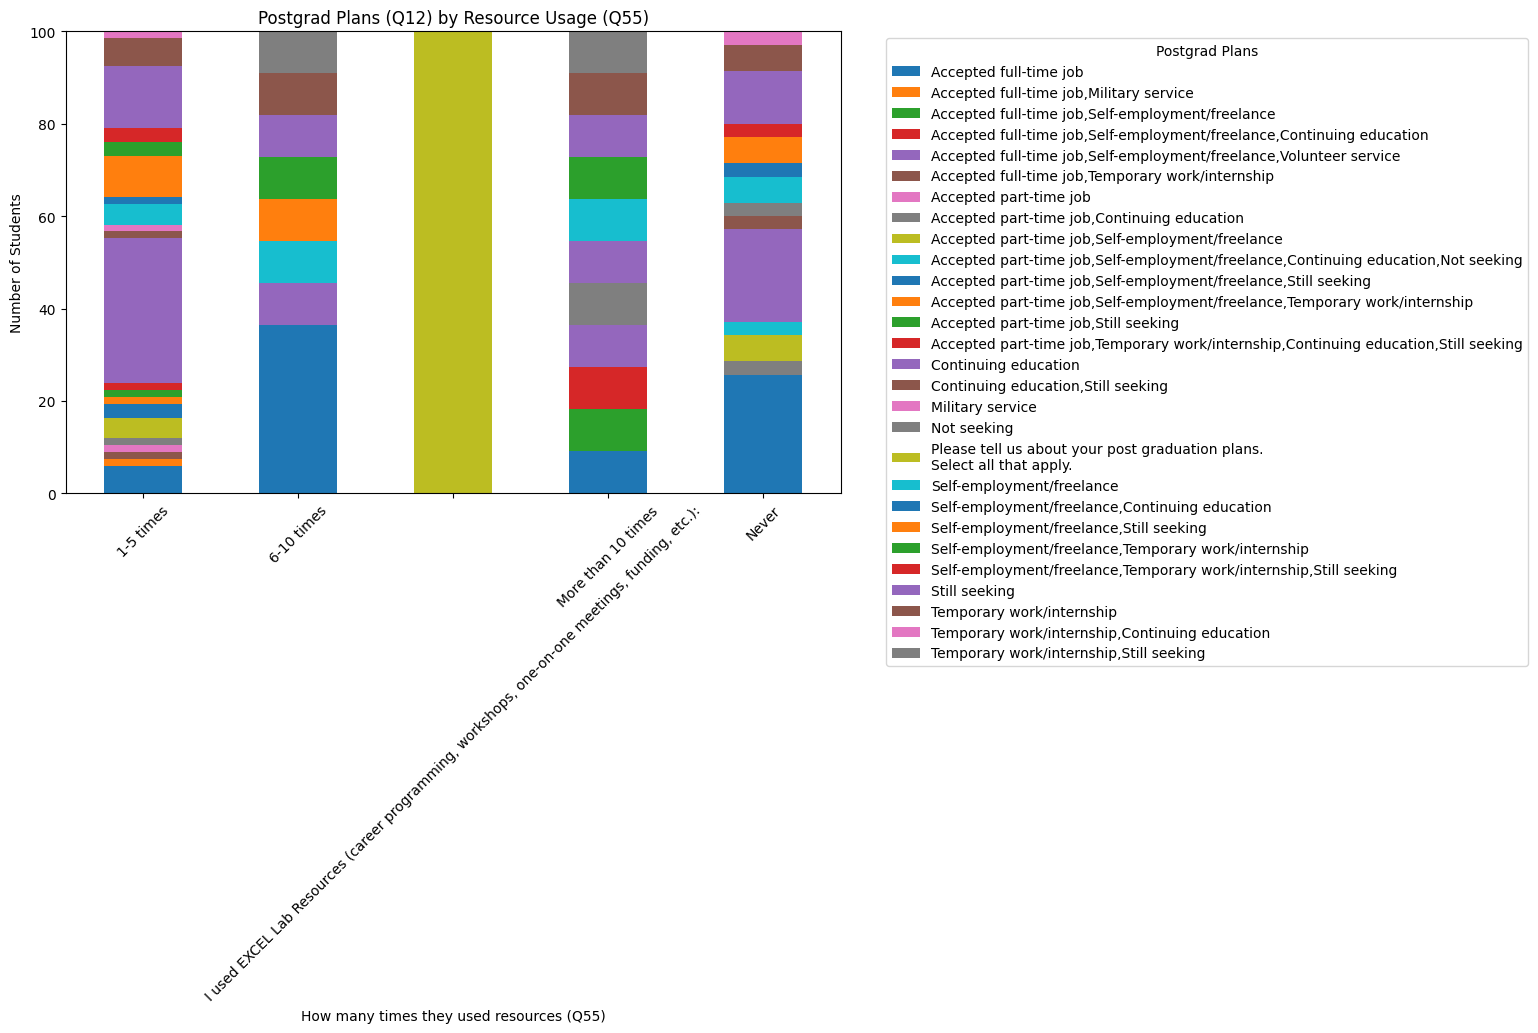

In [12]:
import matplotlib.pyplot as plt

# Plotting the crosstab as a stacked bar chart
analysis_pct.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.title('Postgrad Plans (Q12) by Resource Usage (Q55)')
plt.xlabel('How many times they used resources (Q55)')
plt.ylabel('Number of Students')
plt.legend(title='Postgrad Plans', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.show()

In [13]:
def clean_plans(plan):
    plan = str(plan).lower()
    if 'accepted full-time job' in plan:
        return 'Full-time Employment'
    elif 'accepted part-time job' in plan:
        return 'Part-time Employment'
    elif 'continuing education' in plan:
        return 'Continuing Education'
    elif 'self-employment' in plan or 'freelance' in plan:
        return 'Freelance/Self-Employed'
    elif 'still seeking' in plan:
        return 'Still Seeking'
    else:
        return 'Other/Not Seeking'

# Create a new column with the clean categories
df['Postgrad_Plans_Cleaned'] = df['Q12'].apply(clean_plans)

In [14]:
# Create a mapping to shorten the labels
q55_map = {
    'I used EXCEL Lab Resources (career programming, workshops, one-on-one meetings, funding, etc.):': 'Used Resources',
    'More than 10 times': '>10 times'
}

# Apply the map (if the text matches exactly)
df['Q55_Cleaned'] = df['Q55'].replace(q55_map)

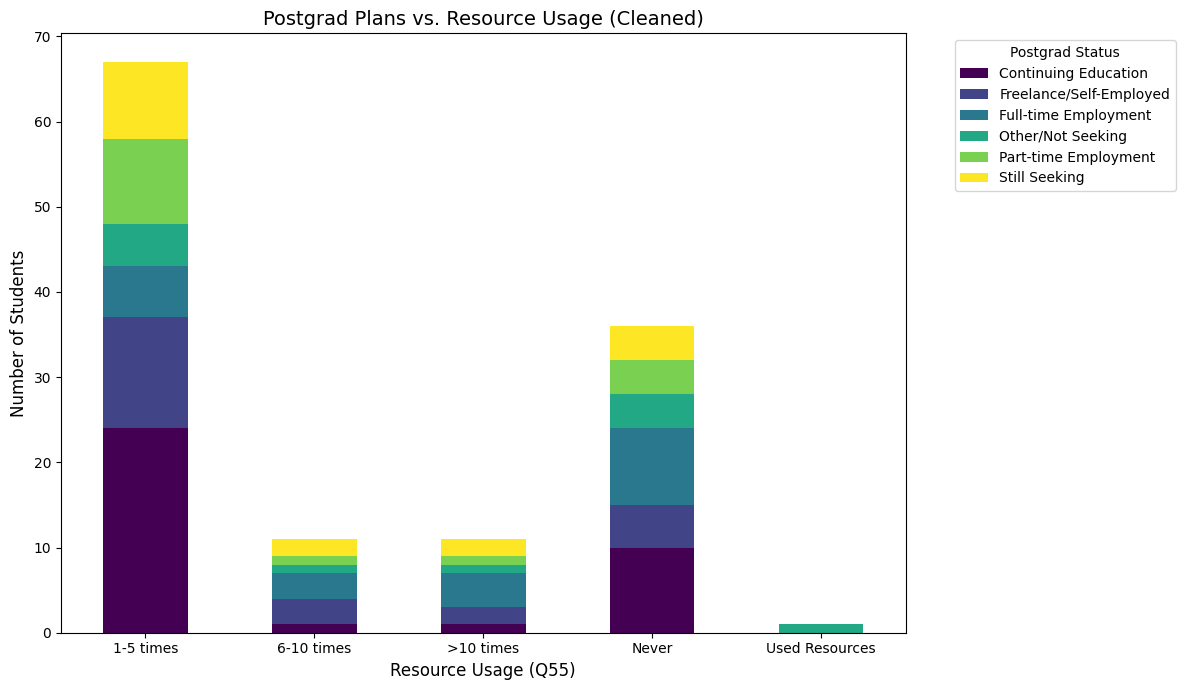

In [15]:
# Re-calculate the crosstab with clean columns
comparison_clean = pd.crosstab(df['Q55_Cleaned'], df['Postgrad_Plans_Cleaned'])

# Plotting
ax = comparison_clean.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')

plt.title('Postgrad Plans vs. Resource Usage (Cleaned)', fontsize=14)
plt.xlabel('Resource Usage (Q55)', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)

# Move legend outside and clean it up
plt.legend(title='Postgrad Status', bbox_to_anchor=(1.05, 1), loc='upper left')

# Improve x-axis readability
plt.xticks(rotation=0) # Set to 0 if labels are short enough, or 45 if they overlap
plt.tight_layout()

plt.show()

In [16]:
# 1. Filter out the instruction text row
# We use != to keep everything EXCEPT that specific long sentence
df_filtered = df[df['Q55'] != 'I used EXCEL Lab Resources (career programming, workshops, one-on-one meetings, funding, etc.):'].copy()

# 2. Re-apply the cleaning function for Q12 (Postgrad Plans)
def clean_plans(plan):
    plan = str(plan).lower()
    if 'accepted full-time job' in plan: return 'Full-time Employment'
    if 'accepted part-time job' in plan: return 'Part-time Employment'
    if 'continuing education' in plan: return 'Continuing Education'
    if 'self-employment' in plan or 'freelance' in plan: return 'Freelance'
    if 'still seeking' in plan: return 'Still Seeking'
    return 'Other'

df_filtered['Postgrad_Plans_Cleaned'] = df_filtered['Q12'].apply(clean_plans)

# 3. Create a Percentage Crosstab (This makes the bars the same height)
# normalize='index' calculates the percentage for each row (each category of Q55)
comparison_pct = pd.crosstab(df_filtered['Q55'], df_filtered['Postgrad_Plans_Cleaned'], normalize='index') * 100

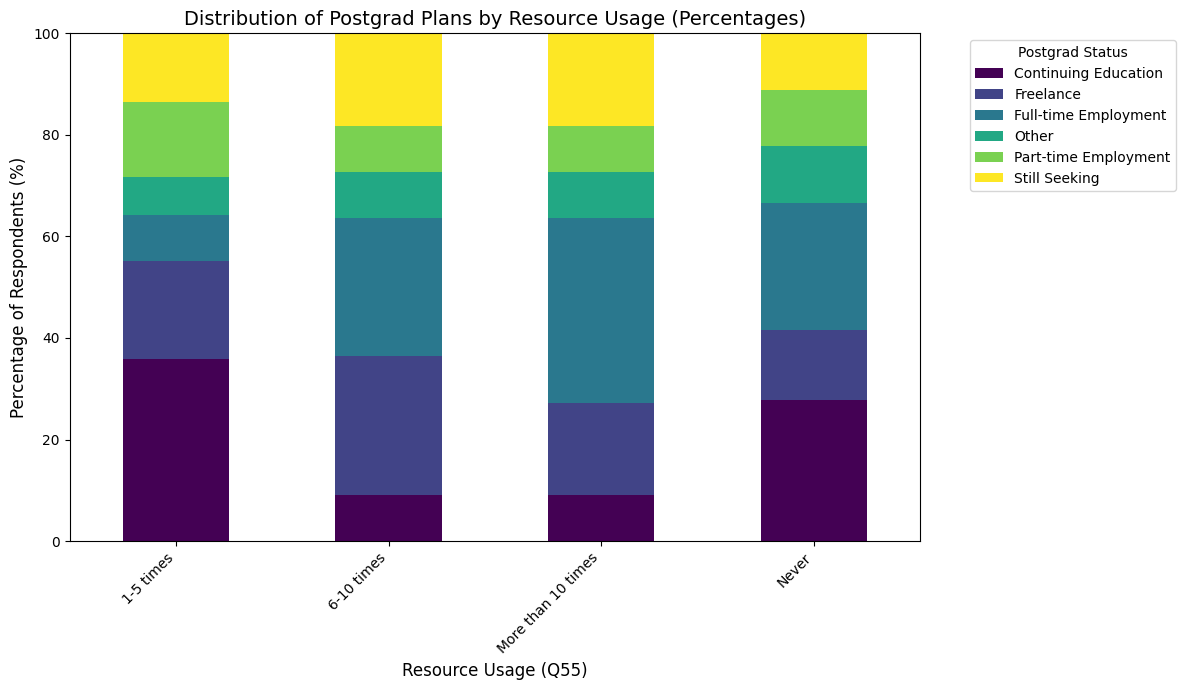

In [17]:
import matplotlib.pyplot as plt

# Plotting the percentage table
ax = comparison_pct.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')

plt.title('Distribution of Postgrad Plans by Resource Usage (Percentages)', fontsize=14)
plt.xlabel('Resource Usage (Q55)', fontsize=12)
plt.ylabel('Percentage of Respondents (%)', fontsize=12)

# Set the Y-axis to always go from 0 to 100
plt.ylim(0, 100)

# Clean up the legend
plt.legend(title='Postgrad Status', bbox_to_anchor=(1.05, 1), loc='upper left')

# Improve x-axis labels (rotate them so they don't overlap)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

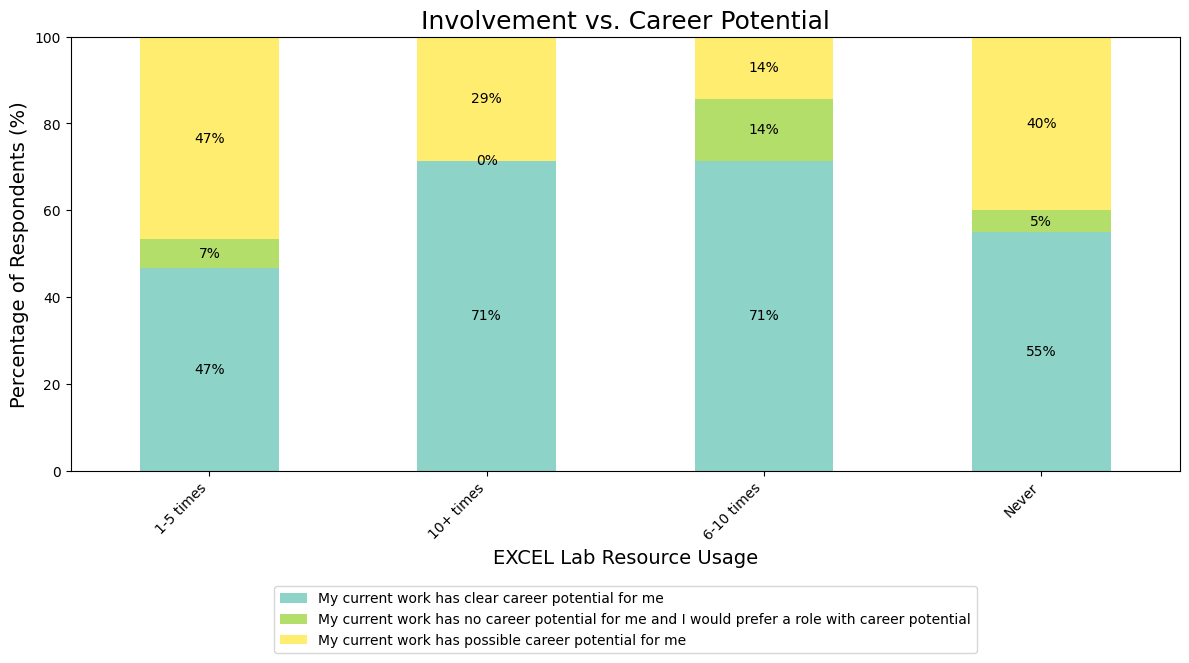

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Filter out the instruction text from Q55 (so it doesn't make a blank bar)
df_filtered = df[df['Q55'] != 'I used EXCEL Lab Resources (career programming, workshops, one-on-one meetings, funding, etc.):'].copy()

# 2. Shorten the Q55 labels for the X-axis (optional, but helps it look neat)
q55_map = {'More than 10 times': '10+ times'}
df_filtered['Q55_Cleaned'] = df_filtered['Q55'].replace(q55_map)

# 3. Create the percentage crosstab using the ORIGINAL, unedited Q42 answers
comparison_raw = pd.crosstab(df_filtered['Q55_Cleaned'], df_filtered['Q42'], normalize='index') * 100

# 4. Plot the chart
ax = comparison_raw.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='Set3')
for container in ax.containers:
    # label_type='center' puts the text in the middle of each stacked block
    # fmt='%.0f%%' rounds to a whole number and adds the % sign (e.g., "45%")
    ax.bar_label(container, label_type='center', fmt='%.0f%%', fontsize=10)
plt.title('Involvement vs. Career Potential', fontsize=18)
plt.xlabel('EXCEL Lab Resource Usage', fontsize=14)
plt.ylabel('Percentage of Respondents (%)', fontsize=14)
plt.ylim(0, 100)

# Move the legend completely outside the plot area so the long text fits
plt.legend(title='', bbox_to_anchor=(0.5, -0.25), loc='upper center')

# Rotate the x-axis labels so they don't overlap
plt.xticks(rotation=45, ha='right')

# tight_layout ensures nothing gets cut off when the image is rendered
plt.tight_layout()

plt.show()